19:29:45 - cmdstanpy - INFO - Chain [1] start processing
19:29:45 - cmdstanpy - INFO - Chain [1] done processing


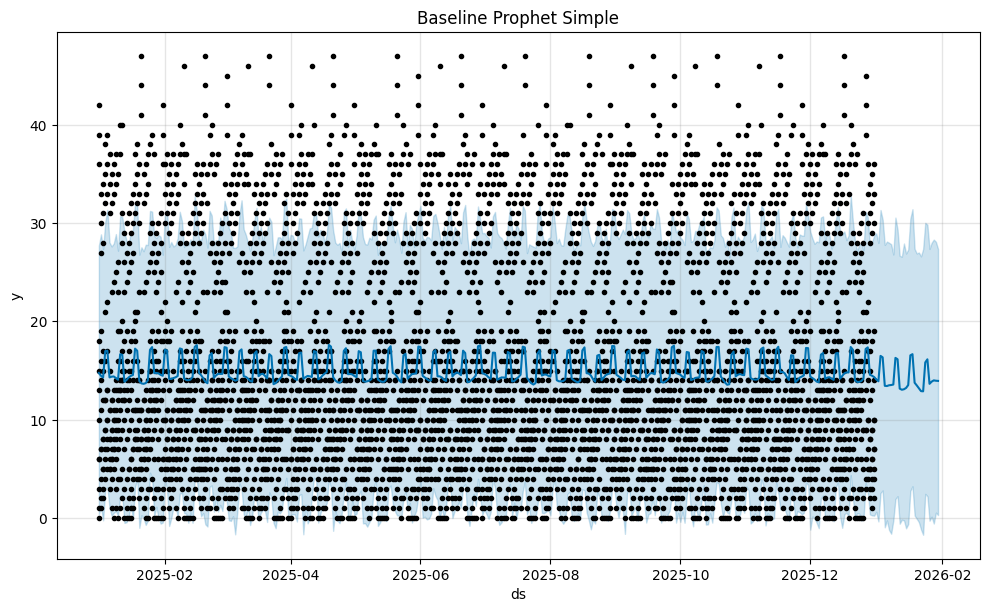

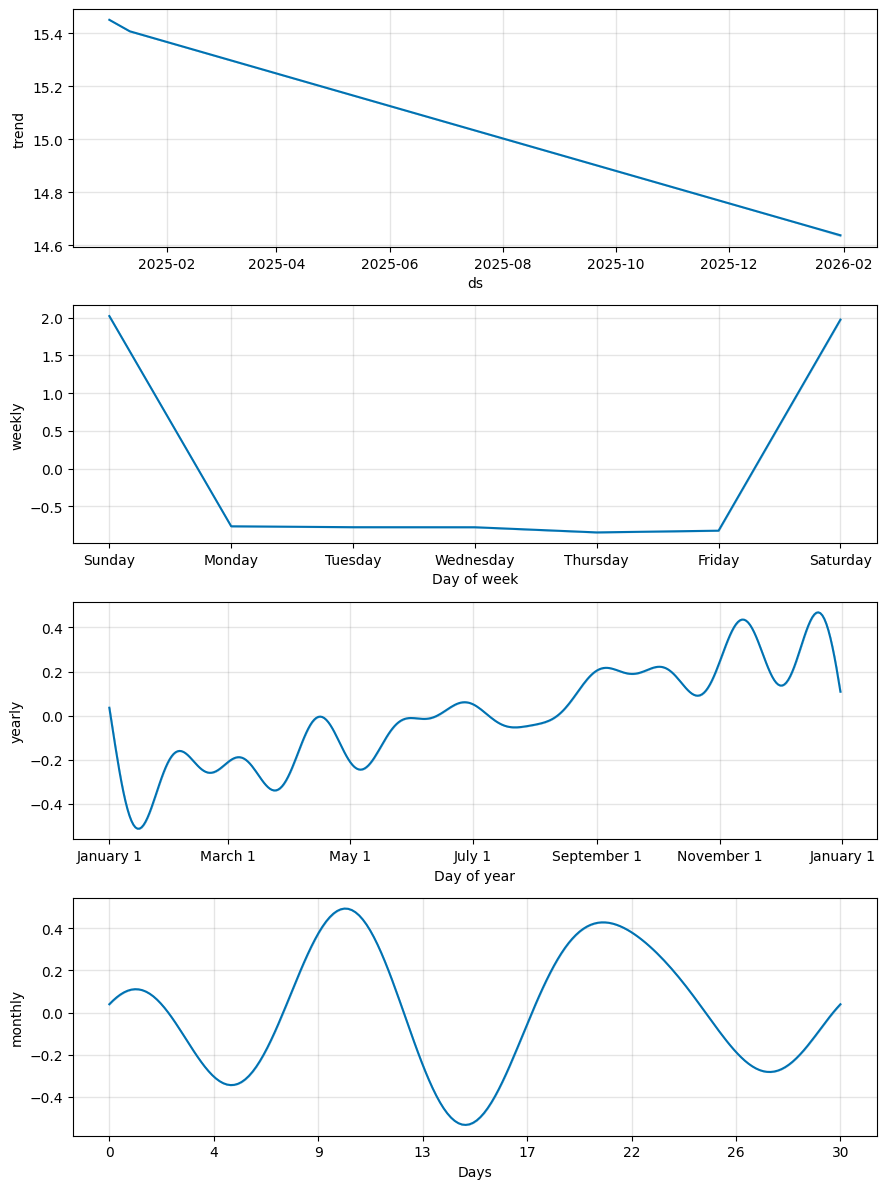

ValueError: Found input variables with inconsistent numbers of samples: [4373, 365]

In [ ]:
import pandas as pd
from pathlib import Path
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import json

PROJECT_ROOT = Path.cwd().parent
CLEAN_PATH = PROJECT_ROOT / "data" / "interim" / "sample_clean.csv"

df = pd.read_csv(CLEAN_PATH, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
df_prophet = df.rename(columns={"date": "ds", "value": "y"})

model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.5
)
model.add_seasonality(name='monthly', period=30.5, fourier_order=5)

# Entraîner le modèle
model.fit(df_prophet)

horizon = 30
future = model.make_future_dataframe(periods=horizon)


forecast = model.predict(future)


model.plot(forecast)
plt.title("Baseline Prophet Simple")
plt.show()

model.plot_components(forecast)
plt.show()

y_true = df_prophet['y']
y_pred = forecast.loc[forecast['ds'].isin(df_prophet['ds']), 'yhat']

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

metrics = {
    "MAE": mae,
    "RMSE": rmse,
    "horizon_days": horizon
}

print("Métriques baseline Prophet simple :", metrics)

FORECAST_PATH = PROJECT_ROOT / "models" / "artifacts" / "prophet_forecast.csv"
METRICS_PATH = PROJECT_ROOT / "models" / "metrics" / "prophet_metrics.json"

FORECAST_PATH.parent.mkdir(parents=True, exist_ok=True)
METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)

forecast.to_csv(FORECAST_PATH, index=False)
with open(METRICS_PATH, "w") as f:
    json.dump(metrics, f, indent=2)

print(f"Forecast sauvegardé : {FORECAST_PATH}")
print(f"Métriques sauvegardées : {METRICS_PATH}")
